# Kilter Board — Exploratory Data Analysis

Explore the Kilter Board database: grade distributions, hold positions, angle effects, and per-hold usage patterns.

In [ ]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
import seaborn as sns  # noqa: E402
from matplotlib.patches import FancyBboxPatch  # noqa: E402

from src.data.ingest import load_climbs, load_difficulty_grades, load_placements  # noqa: E402

sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_columns", 20)

DB_PATH = "../data/raw/kilter.db"


def draw_board(ax, placements_df, board_color="#d4a76a", bolt_color="#888888"):
    """Draw a Kilter Board background with hold bolt positions."""
    board = FancyBboxPatch(
        (-30, -5),
        200,
        190,
        boxstyle="round,pad=5",
        facecolor=board_color,
        edgecolor="#8B6914",
        linewidth=2,
    )
    ax.add_patch(board)
    ax.scatter(
        placements_df["x"],
        placements_df["y"],
        c=bolt_color,
        s=12,
        alpha=0.3,
        zorder=1,
        marker="o",
    )
    ax.set_xlim(-35, 175)
    ax.set_ylim(-10, 185)
    ax.set_aspect("equal")
    ax.set_facecolor(board_color)
    return ax

In [2]:
df = load_climbs(DB_PATH, min_ascents=5)
grades_map = load_difficulty_grades(DB_PATH)
placements = load_placements(DB_PATH)

print(f"Routes (route-angle combos): {len(df):,}")
print(f"Unique routes: {df['climb_uuid'].nunique():,}")
print(f"Angles: {sorted(df['angle'].unique())}")
print(f"Grade range: {df['grade'].min():.1f} – {df['grade'].max():.1f}")
print(f"Hold count range: {df['hold_count'].min()} – {df['hold_count'].max()}")
df.head(3)

Routes (route-angle combos): 67,271
Unique routes: 37,389
Angles: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(60), np.int64(65), np.int64(70)]
Grade range: 10.0 – 31.0
Hold count range: 2 – 306


,climb_uuid,name,angle,grade,ascensionist_count,quality_average,frames,holds,hold_count
0,AC9FCF7F01FC44BD835CFC41CB2224DA,You Don’t Know Me,40,15.9964,77383,2.95790,p1096r15p1113r15p1131r15p1149r12p1166r15p1200r...,"[{'placement_id': 1096, 'x': 56, 'y': 16, 'rol...",14
1,D0E5387D5B974D38B4E93FC4DFD61EF6,Floats Your Boat,40,16.0000,76569,2.96194,p1113r15p1131r15p1144r15p1165r15p1178r15p1198r...,"[{'placement_id': 1113, 'x': 56, 'y': 24, 'rol...",15
2,36E949A6395D4290AF08FDFBCC6010C1,Bell of the Wall,40,18.0000,76388,2.96376,p1169r15p1183r15p1198r15p1234r12p1236r12p1268r...,"[{'placement_id': 1169, 'x': 96, 'y': 48, 'rol...",10


## 1. Grade Distribution

In [ ]:
# Map numeric grades to V-grade labels for readability
grade_labels = grades_map.set_index("difficulty")["boulder_name"].to_dict()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Continuous histogram with dual x-axis (continuous + V-grade)
axes[0].hist(df["grade"], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Grade (continuous)")
axes[0].set_ylabel("Count")
axes[0].set_title("Grade Distribution (continuous scale)")

# Add V-grade labels as secondary x-axis
ax_vgrade = axes[0].twiny()
ax_vgrade.set_xlim(axes[0].get_xlim())
vgrade_ticks = sorted(grade_labels.keys())
vgrade_tick_labels = [grade_labels[t].split("/")[1] for t in vgrade_ticks]  # V-grade only
ax_vgrade.set_xticks(vgrade_ticks[::2])  # every other to avoid crowding
ax_vgrade.set_xticklabels(vgrade_tick_labels[::2], fontsize=8, rotation=45)
ax_vgrade.set_xlabel("V-Grade", fontsize=9)

# Bar chart by V-grade bucket
df["grade_rounded"] = df["grade"].round().astype(int)
df["v_grade"] = df["grade_rounded"].map(grade_labels).fillna("Unknown")
grade_order = grades_map.sort_values("difficulty")["boulder_name"].tolist()
grade_counts = df["v_grade"].value_counts().reindex(grade_order).dropna()
axes[1].bar(range(len(grade_counts)), grade_counts.values, edgecolor="black", alpha=0.7)
axes[1].set_xticks(range(len(grade_counts)))
axes[1].set_xticklabels(grade_counts.index, rotation=45, ha="right")
axes[1].set_ylabel("Count")
axes[1].set_title("Routes per V-Grade")

plt.tight_layout()
plt.show()

median_grade = df["grade"].median()
median_label = grade_labels.get(int(round(median_grade)), "?")
print(f"Median grade: {median_grade:.1f} ({median_label})")
print(f"Mean grade: {df['grade'].mean():.1f}")

## 2. Angle Distribution & Grade vs Angle

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Angle distribution
angle_counts = df["angle"].value_counts().sort_index()
axes[0].bar(angle_counts.index, angle_counts.values, width=4, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Angle (degrees)")
axes[0].set_ylabel("Count")
axes[0].set_title("Routes per Angle")

# Grade vs angle boxplot with V-grade secondary y-axis
axes[1].boxplot(
    [df[df["angle"] == a]["grade"].values for a in sorted(df["angle"].unique())],
    positions=sorted(df["angle"].unique()),
    widths=3,
    manage_ticks=False,
)
axes[1].set_xlabel("Angle (degrees)")
axes[1].set_ylabel("Grade (continuous)")
axes[1].set_title("Grade Distribution by Angle")

# Add V-grade labels on right y-axis
ax_right = axes[1].twinx()
ax_right.set_ylim(axes[1].get_ylim())
vgrade_ticks = sorted(grade_labels.keys())
vgrade_tick_labels = [grade_labels[t].split("/")[1] for t in vgrade_ticks]
ax_right.set_yticks(vgrade_ticks[::2])
ax_right.set_yticklabels(vgrade_tick_labels[::2], fontsize=8)
ax_right.set_ylabel("V-Grade", fontsize=9)

plt.tight_layout()
plt.show()

# Mean grade per angle
mean_by_angle = df.groupby("angle")["grade"].mean()
print("Mean grade by angle:")
for angle, mean in mean_by_angle.items():
    label = grade_labels.get(int(round(mean)), "?")
    print(f"  {angle:2d}°: {mean:.1f} ({label})")

## 3. Hold Position Heatmap\n\nWhich positions on the board are most frequently used across all routes?

In [ ]:
# Explode holds to get one row per hold usage
holds_flat = df.explode("holds").reset_index(drop=True)
holds_expanded = pd.json_normalize(holds_flat["holds"])
holds_expanded["grade"] = holds_flat["grade"].values
holds_expanded["angle"] = holds_flat["angle"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 16))

# Usage frequency heatmap on board background
usage = holds_expanded.groupby(["x", "y"]).size().reset_index(name="count")
draw_board(axes[0], placements)
scatter = axes[0].scatter(
    usage["x"],
    usage["y"],
    c=usage["count"],
    s=usage["count"] / usage["count"].max() * 250,
    cmap="YlOrRd",
    alpha=0.85,
    edgecolors="white",
    linewidths=0.5,
    zorder=2,
)
axes[0].set_title("Hold Usage Frequency", fontsize=14, fontweight="bold")
plt.colorbar(scatter, ax=axes[0], label="Times used", shrink=0.6)

# Top 50 most used holds on board background
draw_board(axes[1], placements)
top_holds = usage.nlargest(50, "count")
scatter2 = axes[1].scatter(
    top_holds["x"],
    top_holds["y"],
    c=top_holds["count"],
    s=120,
    cmap="YlOrRd",
    edgecolors="white",
    linewidths=0.8,
    zorder=2,
)
axes[1].set_title("Top 50 Most Used Holds", fontsize=14, fontweight="bold")
plt.colorbar(scatter2, ax=axes[1], label="Times used", shrink=0.6)

plt.tight_layout()
plt.show()

## 4. Hold Count vs Grade

In [ ]:
# Filter out outlier hold counts for cleaner visualization
df_viz = df[df["hold_count"] <= 30]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_viz["hold_count"], df_viz["grade"], alpha=0.05, s=5)
axes[0].set_xlabel("Hold Count")
axes[0].set_ylabel("Grade (continuous)")
axes[0].set_title("Hold Count vs Grade")

# V-grade right axis on scatter
ax0_r = axes[0].twinx()
ax0_r.set_ylim(axes[0].get_ylim())
vg_ticks = [t for t in sorted(grade_labels.keys()) if t % 2 == 0]
vg_labels = [grade_labels[t].split("/")[1] for t in vg_ticks]
ax0_r.set_yticks(vg_ticks)
ax0_r.set_yticklabels(vg_labels, fontsize=8)
ax0_r.set_ylabel("V-Grade", fontsize=9)

# Mean grade by hold count
mean_by_holds = df_viz.groupby("hold_count")["grade"].agg(["mean", "std", "count"])
mean_by_holds = mean_by_holds[mean_by_holds["count"] >= 10]
axes[1].errorbar(
    mean_by_holds.index,
    mean_by_holds["mean"],
    yerr=mean_by_holds["std"],
    fmt="o-",
    capsize=3,
    markersize=4,
)
axes[1].set_xlabel("Hold Count")
axes[1].set_ylabel("Mean Grade ± 1 SD")
axes[1].set_title("Mean Grade by Hold Count")

# V-grade right axis on errorbar
ax1_r = axes[1].twinx()
ax1_r.set_ylim(axes[1].get_ylim())
ax1_r.set_yticks(vg_ticks)
ax1_r.set_yticklabels(vg_labels, fontsize=8)
ax1_r.set_ylabel("V-Grade", fontsize=9)

plt.tight_layout()
plt.show()

print(f"Correlation (hold_count vs grade): {df_viz['hold_count'].corr(df_viz['grade']):.3f}")

## 5. Ascent Count Distribution

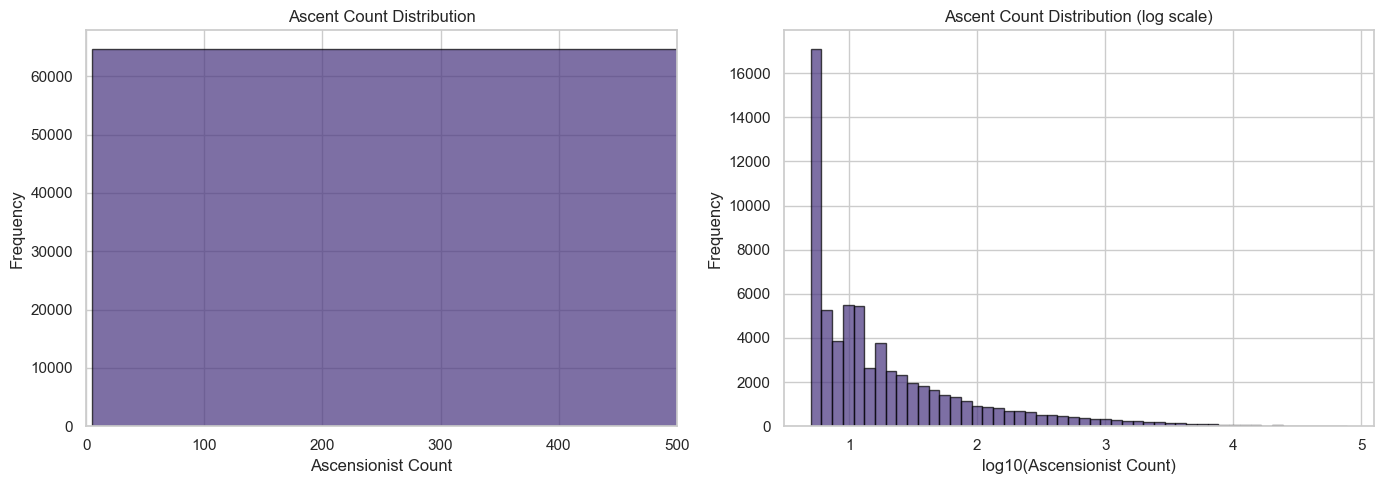

Median ascents: 11
Mean ascents: 205
Max ascents: 77383


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["ascensionist_count"], bins=100, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Ascensionist Count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Ascent Count Distribution")
axes[0].set_xlim(0, 500)

axes[1].hist(np.log10(df["ascensionist_count"]), bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("log10(Ascensionist Count)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Ascent Count Distribution (log scale)")

plt.tight_layout()
plt.show()

print(f"Median ascents: {df['ascensionist_count'].median():.0f}")
print(f"Mean ascents: {df['ascensionist_count'].mean():.0f}")
print(f"Max ascents: {df['ascensionist_count'].max()}")

## 6. Per-Hold Usage Analysis (Hold Usability Preview)\n\nFor each hold position, compute the mean grade of routes it appears in. This previews the \"hold usability\" feature we'll engineer in Phase 3 — the hypothesis is that holds appearing in easy routes even at steep angles are \"good\" holds (jug-like), while holds only appearing in hard routes are \"bad\" holds (crimp-like).

In [ ]:
# Per-hold statistics: mean grade, usage count, mean angle
hold_stats = (
    holds_expanded.groupby(["x", "y"])
    .agg(
        mean_grade=("grade", "mean"),
        std_grade=("grade", "std"),
        mean_angle=("angle", "mean"),
        usage_count=("grade", "size"),
    )
    .reset_index()
)

# Filter to holds used in at least 20 routes for stable estimates
hold_stats_filtered = hold_stats[hold_stats["usage_count"] >= 20]

fig, axes = plt.subplots(1, 3, figsize=(20, 14))

# --- Mean grade heatmap with V-grade colorbar ---
draw_board(axes[0], placements)
scatter1 = axes[0].scatter(
    hold_stats_filtered["x"],
    hold_stats_filtered["y"],
    c=hold_stats_filtered["mean_grade"],
    s=hold_stats_filtered["usage_count"] / hold_stats_filtered["usage_count"].max() * 200,
    cmap="RdYlGn_r",
    alpha=0.85,
    edgecolors="white",
    linewidths=0.5,
    zorder=2,
)
axes[0].set_title("Mean Grade per Hold\n(size = usage count)", fontsize=13, fontweight="bold")
cbar1 = plt.colorbar(scatter1, ax=axes[0], shrink=0.6)
# V-grade ticks on the colorbar
vg_ticks = [t for t in sorted(grade_labels.keys()) if t % 2 == 0]
vg_labels = [grade_labels[t].split("/")[1] for t in vg_ticks]
cbar1.set_ticks(vg_ticks)
cbar1.set_ticklabels(vg_labels)
cbar1.set_label("V-Grade")

# --- Grade variability (std) heatmap ---
draw_board(axes[1], placements)
scatter2 = axes[1].scatter(
    hold_stats_filtered["x"],
    hold_stats_filtered["y"],
    c=hold_stats_filtered["std_grade"],
    s=80,
    cmap="YlOrRd",
    alpha=0.85,
    edgecolors="white",
    linewidths=0.5,
    zorder=2,
)
axes[1].set_title("Grade Variability (SD) per Hold", fontsize=13, fontweight="bold")
plt.colorbar(scatter2, ax=axes[1], label="Grade SD", shrink=0.6)

# --- Mean angle heatmap ---
draw_board(axes[2], placements)
scatter3 = axes[2].scatter(
    hold_stats_filtered["x"],
    hold_stats_filtered["y"],
    c=hold_stats_filtered["mean_angle"],
    s=80,
    cmap="coolwarm",
    alpha=0.85,
    edgecolors="white",
    linewidths=0.5,
    zorder=2,
)
axes[2].set_title("Mean Angle per Hold\n(red = steeper angles)", fontsize=13, fontweight="bold")
plt.colorbar(scatter3, ax=axes[2], label="Mean angle (°)", shrink=0.6)

plt.tight_layout()
plt.show()

grade_min = hold_stats_filtered["mean_grade"].min()
grade_max = hold_stats_filtered["mean_grade"].max()
print(f"Holds with ≥20 uses: {len(hold_stats_filtered)}")
print(f"Mean grade range across holds: {grade_min:.1f} – {grade_max:.1f}")
vmin_label = grade_labels.get(int(round(grade_min)), "?")
vmax_label = grade_labels.get(int(round(grade_max)), "?")
print(f"  Easiest holds average: {vmin_label} | Hardest holds average: {vmax_label}")
print(
    f"This {grade_max - grade_min:.1f}-point spread confirms holds vary "
    "in difficulty — supporting the usability feature."
)

## 7. Save Processed Data to Parquet

In [ ]:
# Save processed climb data (without list columns — parquet can't store them directly)
# We'll save the frames string and re-parse as needed in feature engineering
df_save = df.drop(columns=["holds"]).copy()
df_save.to_parquet("../data/processed/climbs.parquet", index=False)
print(f"Saved climbs.parquet: {len(df_save):,} rows")

# Save placements
placements.to_parquet("../data/processed/placements.parquet", index=False)
print(f"Saved placements.parquet: {len(placements):,} rows")

# Save per-hold stats for later use in hold usability feature
hold_stats.to_parquet("../data/processed/hold_stats.parquet", index=False)
print(f"Saved hold_stats.parquet: {len(hold_stats):,} rows")